---
title: GSB545 Advanced Machine Learning
author: Alexa Dandridge
format:
    html:
        embed-resources: true
        code-line numbers: true

---

### **Part 1 - About You (10 Points)**

**-Why are you pursuing the MSBA program?**

I am pursuing the MSBA program because I was determined to earn my Master's Degree in a subject that would be meaningful and impactful for myself. I wanted to take every opportunity to set my future up for success, and the MSBA combined business and technology, which I find so interesting. 

**-What did you do before entering the program?**

Before entering the program, I earned my B.S. in Business Administration with a Focus in Marketing. I graduated a semester early from undergrad, so I spent that time coaching track and field at Buchanan High School!

**-What type of role, industry, or company are you interested in after graduation?** 

I would be fulfilled in a data science or business analyst role. I am interested in multiple different industries, but overall, I would love to be able to use technology to make a positive, meaningful impact on people or a company. Some of my top interests include sports, space, entertainment, medical, or technology. 

**-What topics or methods are you most interested in learning in this course?**


I am interesting in learning more abut effective ways to choose models based on the business scenario. I also want to learn how to better interpret models and apply insights. One topic that I am most interested is neural networks because I do not know how these work at all. 

### **Part 2 - Cost of Living & Salary (30 Points)**

In [12]:
# Installing pandas and plotnine packages because importing was not working at first
import sys
!{sys.executable} -m pip install pandas plotnine

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [13]:
# Importing necessary libraries - pandas and plotnine
import pandas as pd
from plotnine import *

In [14]:
# Creating a dictionary with the cost of living data
locations = {
    "San Antonio, TX": {
        "housing": 1600,
        "food": 450,
        "transportation": 250,
        "pet_food" : 60,
        "utilities": 180,
        "healthcare": 220,
        "miscellaneous": 300,
        "savings_rate": 0.15,
        "tax_rate": 0.22,
        "desired_extra": 2000
    },
    "San Luis Obispo, CA": {
        "housing": 2100,
        "food": 500,
        "transportation": 280,
        "pet_food" : 60,
        "utilities": 190,
        "healthcare": 230,
        "miscellaneous": 350,
        "savings_rate": 0.15,
        "tax_rate": 0.30,
        "desired_extra": 1500
    },
    "Clovis, CA": {
        "housing": 2400,
        "food": 550,
        "transportation": 300,
        "pet_food" : 60,
        "utilities": 200,
        "healthcare": 240,
        "miscellaneous": 400,
        "savings_rate": 0.15,
        "tax_rate": 0.25,
        "desired_extra": 1800
    }
}

In [15]:
# Creating calculations

# Turning the dictionary into an actual dataframe table and transposing
df = pd.DataFrame(locations).T

# Defining what columns will count as monthly expenses
expense_cols = [
    "housing", "food", "transportation",
    "pet_food", "utilities", "healthcare", "miscellaneous"
]

# Calculation 1: Adding up the monthly expenses defined above
df["monthly_cost"] = df[expense_cols].sum(axis=1)
# Calculation 2: Multiplying to find annual cost of defined expenses from monthly costs
df["annual_cost"] = df["monthly_cost"] * 12
# Calculation 3: Calculates minimum annual salary (adjusted for after taxes)
df["minimum_annual_salary"] = df["annual_cost"] / (1 - df["tax_rate"])
# Calculation 4: Finding the desired annual salary
df["desired_annual_salary"] = (
    (df["annual_cost"] + df["desired_extra"] * 12) /
    (1 - df["tax_rate"] - df["savings_rate"])
)

df

,housing,food,transportation,pet_food,utilities,healthcare,miscellaneous,savings_rate,tax_rate,desired_extra,monthly_cost,annual_cost,minimum_annual_salary,desired_annual_salary
"San Antonio, TX",1600.0,450.0,250.0,60.0,180.0,220.0,300.0,0.15,0.22,2000.0,3060.0,36720.0,47076.923077,96380.952381
"San Luis Obispo, CA",2100.0,500.0,280.0,60.0,190.0,230.0,350.0,0.15,0.30,1500.0,3710.0,44520.0,63600.000000,113672.727273
"Clovis, CA",2400.0,550.0,300.0,60.0,200.0,240.0,400.0,0.15,0.25,1800.0,4150.0,49800.0,66400.000000,119000.000000


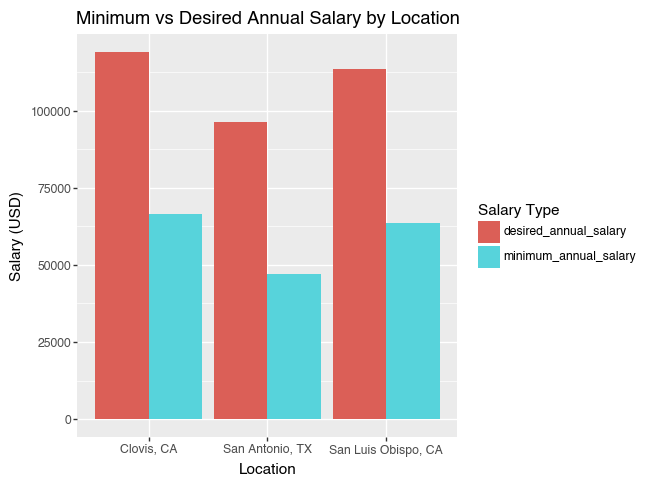

In [16]:
# Creating a plot to represent the minimum and desired salary based on location

# Reshaping the table (wide to long format)
plot_df = df.reset_index().melt(
    id_vars="index",
    value_vars=["minimum_annual_salary", "desired_annual_salary"],
    var_name="salary_type",
    value_name="salary"
)

plot_df = plot_df.rename(columns={"index": "location"})

# Creating a bar chart
(
    ggplot(plot_df, aes(x="location", y="salary", fill="salary_type"))
    + geom_bar(stat="identity", position="dodge")
    + labs(
        title="Minimum vs Desired Annual Salary by Location",
        x="Location",
        y="Salary (USD)",
        fill="Salary Type"
    )
)

### **Part 3 - Reflection (10 Points)**

**-Did your notebook run successfully from start to finish?**

The only thing that did not run successfully for me was importing pandas. Once I reinstalled, it worked and the rest of the notebook ran successfully!

**-How long did this assignment take you?**

This entire assignment took me about 45 minutes. I needed to brush up on some of my skills since I had a semester off from machine learning. 

**-What is one technical skill you feel confident about, and one you want to strengthen?**

I feel confident about creating simple models and basic visualizations, and I want to strengthen my skills by broadening my knowledge on new models that may be more effective for certain business cases. I also want to feel more confident in structuring the data in formats that are effective. Wide and long formats, for example, get mixed up for me at times. 